Datos entrada: Datos\01_Optimización\Opt_dataset_4Objectives_CC.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

COLOR_BASE = "#00929a"
COLOR_OSCURO = "#006d73"
COLOR_CLARO = "#4bb8be"
COLOR_MUY_CLARO = "#d9f1f2"
COLOR_GRID = "#b7dfe2"
COLOR_TEXTO = "#1f2d2f"


plt.rcParams.update({
    "text.color": COLOR_TEXTO,
    "axes.labelcolor": COLOR_TEXTO,
    "xtick.color": COLOR_TEXTO,
    "ytick.color": COLOR_TEXTO,
    "axes.edgecolor": COLOR_OSCURO,
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.axisbelow": True  
})


In [ ]:
df = pd.read_csv(r'Datos\01_Optimización\Opt_dataset_4Objectives_CC.csv')
rename_dict = {
    'x1': 'hm','x2': 'alfa_m',
    'x3': 'er','x4': 'dsi',
    'x5': 'bst','x6': 'bss',
    'y1': 'TC','y2': 'cogging',
    'y3': '-η_ed','y4': 'ripple'
}

df.rename(columns=rename_dict, inplace=True)
features = ['hm', 'alfa_m', 'er', 'dsi', 'bst', 'bss']
objectives = ['TC', 'cogging', '-η_ed', 'ripple']

print("Columns:", df.columns.tolist())
df2 = df.copy()
df2['-η_ed'] = df2['-η_ed']*-1
desc = df2.describe()
print("\nDescriptive Statistics:")
print(desc)

Columns: ['hm', 'alfa_m', 'er', 'dsi', 'bst', 'bss', 'TC', 'cogging', '-η_ed', 'ripple']

Descriptive Statistics:
                hm       alfa_m           er          dsi          bst  \
count  1700.000000  1700.000000  1700.000000  1700.000000  1700.000000   
mean      2.161765     0.858353     1.404647     0.993353    46.152941   
std       1.106701     0.096439     0.414633     0.951618     1.129553   
min       1.000000     0.700000     0.600000     0.000000    45.000000   
25%       1.200000     0.750000     1.100000     0.100000    45.000000   
50%       1.600000     0.900000     1.400000     0.700000    46.000000   
75%       3.200000     0.900000     1.800000     2.100000    46.500000   
max       4.000000     1.000000     2.000000     2.500000    49.500000   

               bss           TC      cogging        -η_ed       ripple  
count  1700.000000  1700.000000  1700.000000  1700.000000  1700.000000  
mean      4.729353     6.190064     0.075674     0.881333     0.090869  


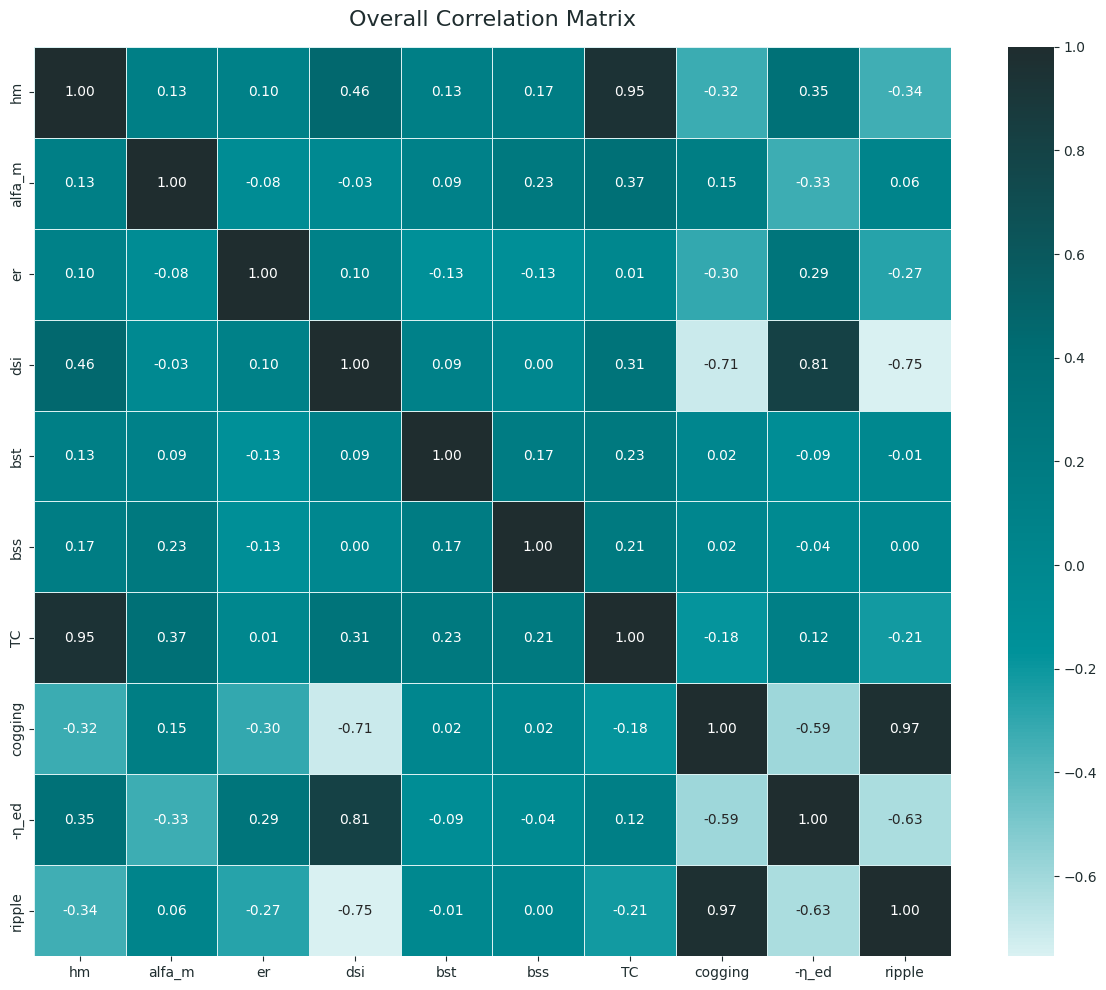

In [ ]:
cmap_correlacion = LinearSegmentedColormap.from_list(
    "custom_palette", [COLOR_MUY_CLARO, COLOR_BASE, COLOR_OSCURO, COLOR_TEXTO])

colores_objetivos = [COLOR_OSCURO, COLOR_BASE, COLOR_CLARO, COLOR_MUY_CLARO]

plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap=cmap_correlacion, fmt=".2f", linewidths=0.5, linecolor=COLOR_MUY_CLARO)
plt.title("Overall Correlation Matrix", fontsize=16, color=COLOR_TEXTO, pad=15)
plt.tight_layout()
plt.show()


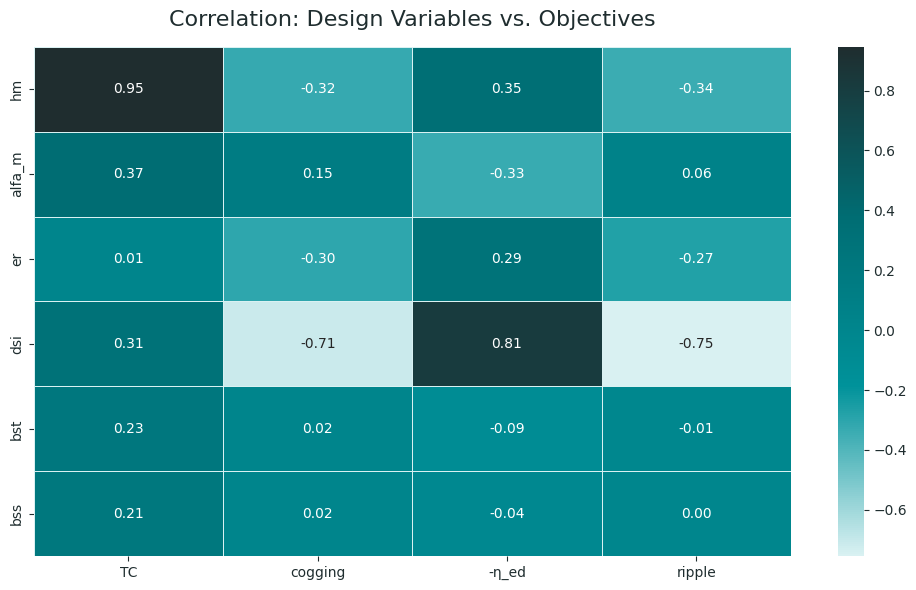

In [ ]:
plt.figure(figsize=(10, 6))
corr_subset = df[features + objectives].corr().loc[features, objectives]
sns.heatmap(corr_subset, annot=True, cmap=cmap_correlacion, fmt=".2f", linewidths=0.5, linecolor=COLOR_MUY_CLARO)
plt.title("Correlation: Design Variables vs. Objectives", fontsize=16, color=COLOR_TEXTO, pad=15)
plt.tight_layout()
plt.show()

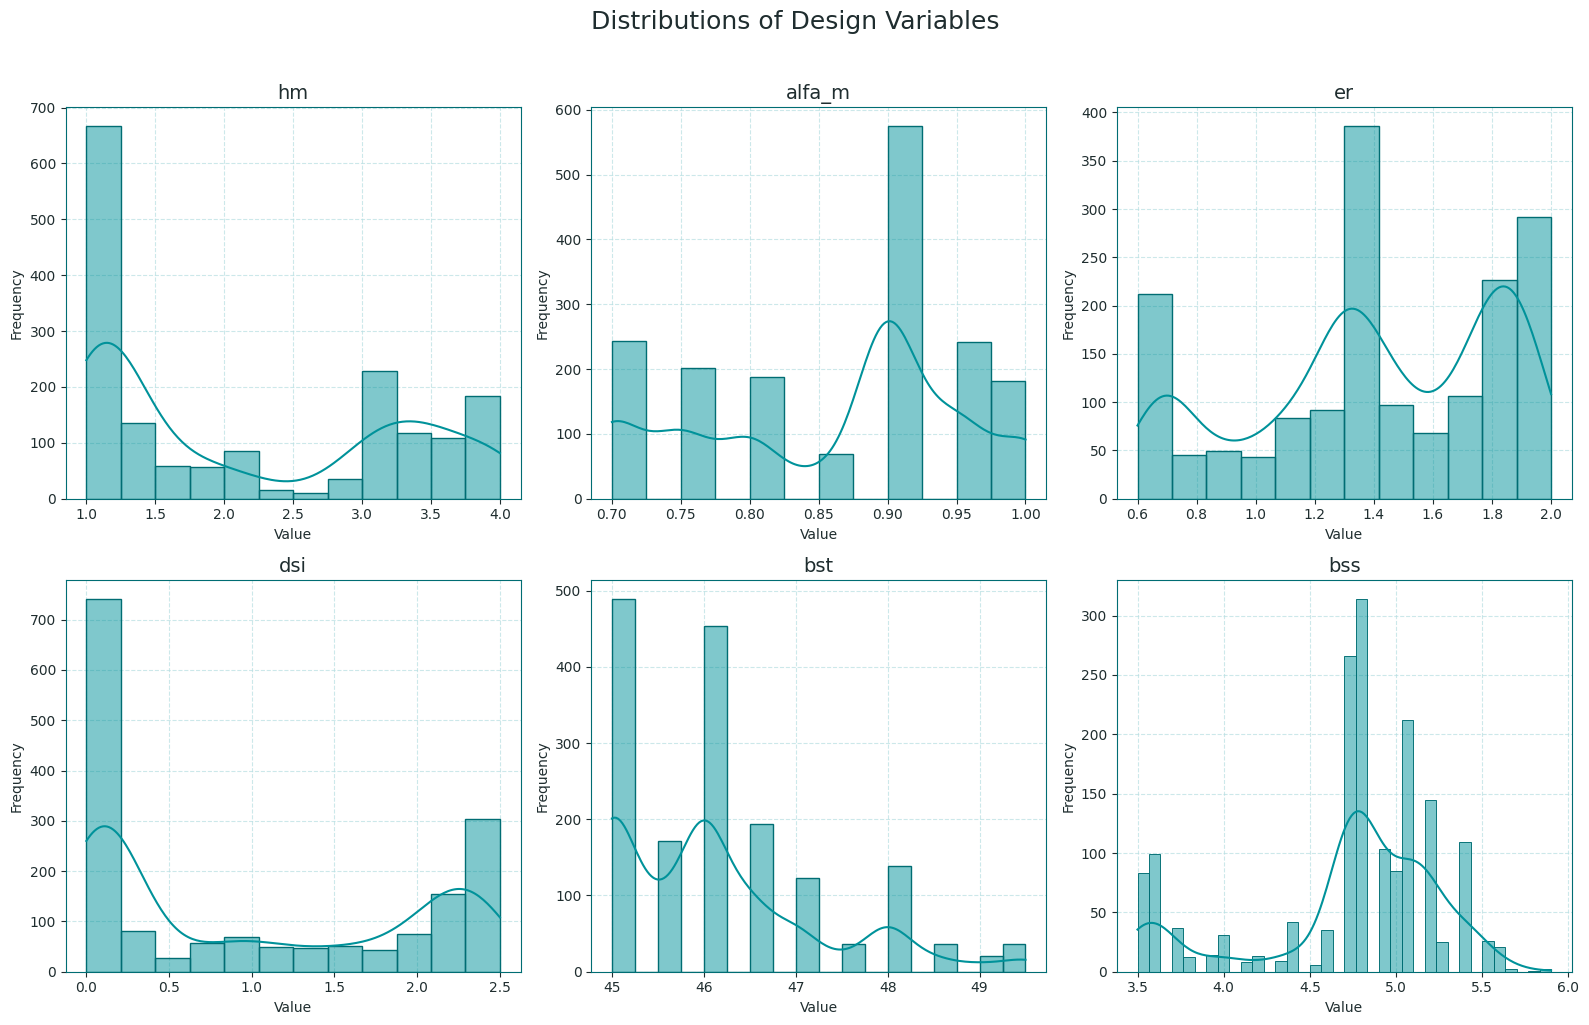

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distributions of Design Variables', fontsize=18, color=COLOR_TEXTO, y=1.02)
for i, col in enumerate(features):
    ax = axes[i//3, i%3]
    sns.histplot(df[col], kde=True, color=COLOR_BASE, edgecolor=COLOR_OSCURO, ax=ax)
    
    ax.set_title(col, fontsize=14, color=COLOR_TEXTO)
    
    ax.set_xlabel('Value', color=COLOR_TEXTO)
    ax.set_ylabel('Frequency', color=COLOR_TEXTO)

plt.tight_layout()
plt.show()

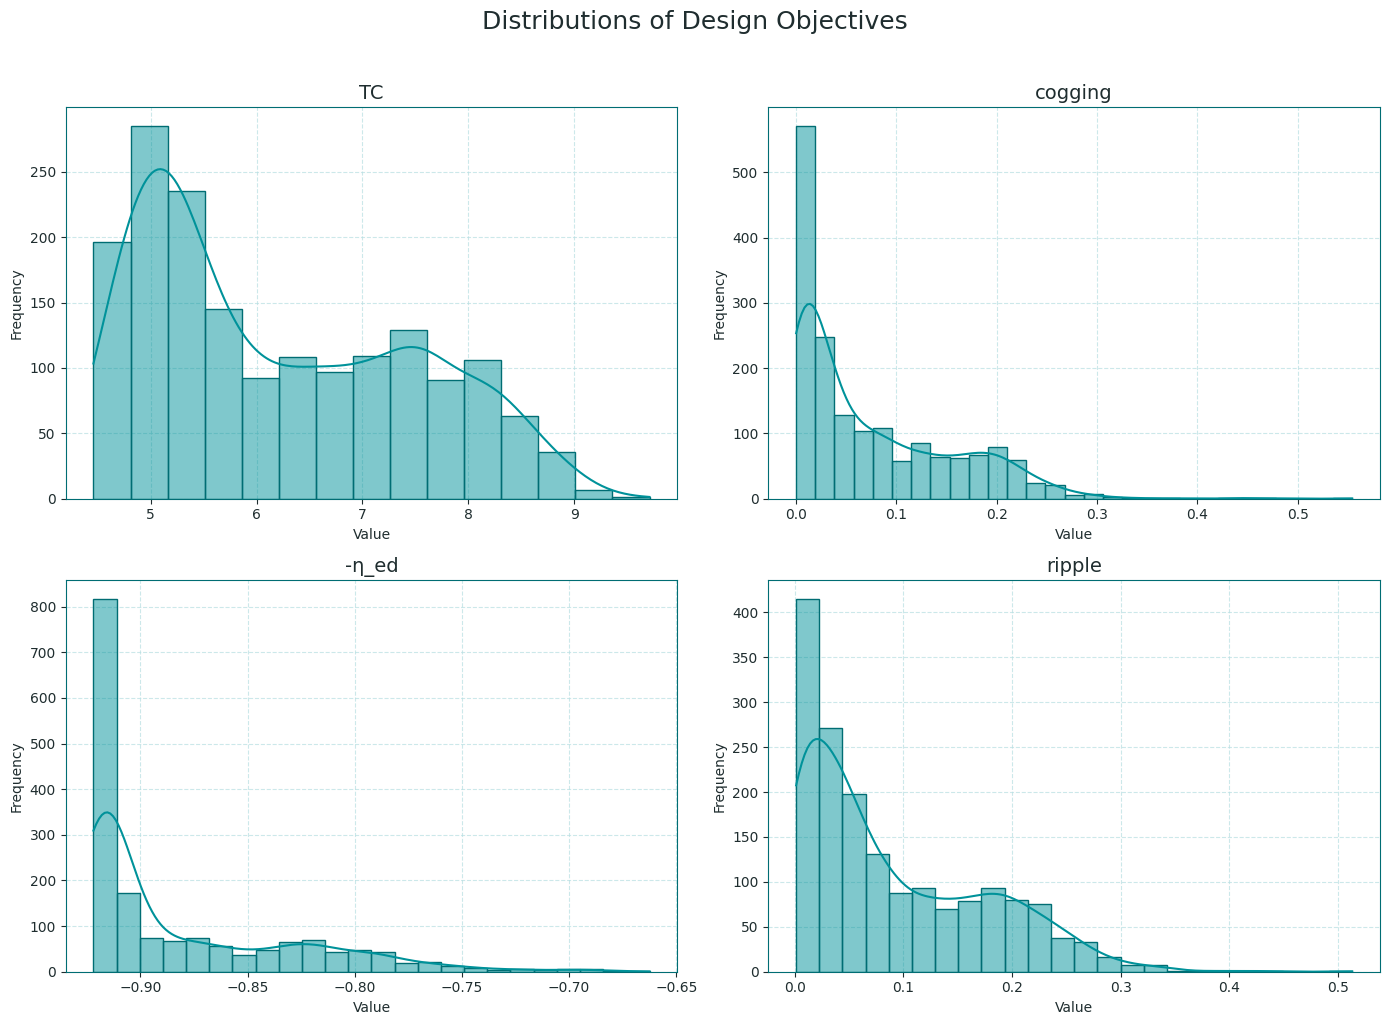

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distributions of Design Objectives', fontsize=18, color=COLOR_TEXTO, y=1.02)
for i, col in enumerate(objectives):
    ax = axes[i//2, i%2]
    sns.histplot(df[col], kde=True, color=COLOR_BASE, edgecolor=COLOR_OSCURO, ax=ax)
    ax.set_title(col, fontsize=14, color=COLOR_TEXTO)
    ax.set_xlabel('Value', color=COLOR_TEXTO)
    ax.set_ylabel('Frequency', color=COLOR_TEXTO)
plt.tight_layout()
plt.show()